<a href="https://colab.research.google.com/github/Briyad37/Convolutional-Neural-Networks-TomatoDoc-Models/blob/main/leaf_or_notleaf_classification_inceptionV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\\## Importing the necessary libraries

> Add blockquote



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential, save_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
import tensorflow_hub as hub
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import InceptionV3
import tensorflow as tf

## Getting the path of the training and testing data of the image dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_directory_location = '/content/drive/MyDrive/ColabNotebooks/Tomato_disease_detection/image_dataset'

In [ ]:
os.listdir(dataset_directory_location)

['test', 'train']

In [ ]:
train_dataset_location = os.path.join(dataset_directory_location, 'train')
test_dataset_location = os.path.join(dataset_directory_location, 'test')

In [ ]:
os.listdir(train_dataset_location)

['leaf', 'not_leaf']

In [ ]:
os.listdir(test_dataset_location)

['leaf', 'not_leaf']

## Viewing a sample image from the dataset

In [ ]:
image_sample = os.path.join(train_dataset_location, 'not_leaf')

In [ ]:
os.listdir(image_sample)[:1]

['01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG']

In [ ]:
image_sample_read = imread(os.path.join(image_sample, '01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'))

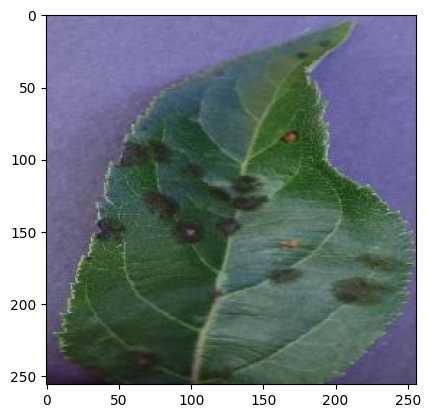

In [ ]:
plt.imshow(image_sample_read)

In [ ]:
image_sample_read.shape

(256, 256, 3)

::\\## Defining the correct shape of the image

In [ ]:
correct_image_shape = (224, 224, 3)

## Defining the ImageGenerator and performing Data Augmentation

In [ ]:
image_gen = ImageDataGenerator(rotation_range=20,
                               width_shift_range=0.1,
                               height_shift_range=0.1,
                               shear_range=0.1,
                               zoom_range=0.1,
                               horizontal_flip=True,
                               fill_mode='nearest',
                               rescale=1./255)

In [ ]:
train_image_gen = image_gen.flow_from_directory(train_dataset_location,
                                                target_size=correct_image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=16,
                                                class_mode='binary')

test_image_gen = image_gen.flow_from_directory(test_dataset_location,
                                                target_size=correct_image_shape[:2],
                                                color_mode='rgb',
                                                batch_size=16,
                                                class_mode='binary')

Found 1620 images belonging to 2 classes.
Found 1014 images belonging to 2 classes.


## Creating and training the model

In [ ]:
# model = Sequential()

In [ ]:
# get_inception_v2_pretrained_model = "https://www.kaggle.com/models/google/inception-v2/TensorFlow2/feature-vector/2"

In [ ]:
base_model = InceptionV3(input_shape=correct_image_shape, include_top=False, weights='imagenet')
base_model.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = Input(shape=correct_image_shape)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=outputs)

In [ ]:
model.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.00001), metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,804,833 (83.18 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,804,833 (83.18 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
model.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.00001), metrics=['accuracy'])

In [ ]:
model.fit(train_image_gen, validation_data=test_image_gen, epochs=30)

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 714s 7s/step - accuracy: 0.5574 - loss: 0.7259 - val_accuracy: 0.4724 - val_loss: 0.7646
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 495ms/step - accuracy: 0.5691 - loss: 0.6843 - val_accuracy: 0.5572 - val_loss: 0.6860
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 487ms/step - accuracy: 0.6154 - loss: 0.6459 - val_accuracy: 0.6203 - val_loss: 0.6369
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 500ms/step - accuracy: 0.6420 - loss: 0.6280 - val_accuracy: 0.6578 - val_loss: 0.6221
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 496ms/step - accuracy: 0.6679 - loss: 0.6012 - val_accuracy: 0.6706 - val_loss: 0.5968
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 549ms/step - accuracy: 0.7012 - loss: 0.5899 - val_accuracy: 0.7110 - val_loss: 0.5704
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 57s 565ms/step - accuracy: 0.6920 - loss: 0.5781 - val_accuracy: 0.7219 - val_loss: 0.5467
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 60s 590ms/step - accuracy: 0.7284 - loss: 0.5

In [ ]:
history_df = pd.DataFrame(model.history.history)

<Axes: >

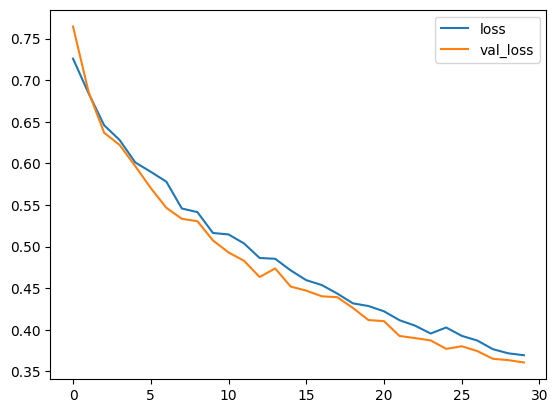

In [ ]:
history_df[['loss', 'val_loss']].plot()

<Axes: >

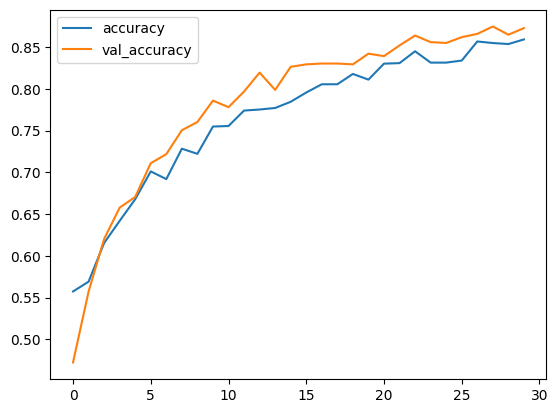

In [ ]:
history_df[['accuracy', 'val_accuracy']].plot()

## Evaluating the model

In [ ]:
model.evaluate(train_image_gen)[1]

102/102 ━━━━━━━━━━━━━━━━━━━━ 37s 363ms/step - accuracy: 0.8469 - loss: 0.3713


0.8469135761260986

In [ ]:
model.evaluate(test_image_gen)[1]

64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.8767 - loss: 0.3583


0.8767258524894714

## Predicting on a sample image

In [ ]:
sample_img_load = image.load_img(os.path.join(test_dataset_location, 'not_leaf', '4b837c0f-15e7-4896-9a4c-2f5ea9fbb5de___Mt.N.V_HL 6195.JPG'), target_size=correct_image_shape)

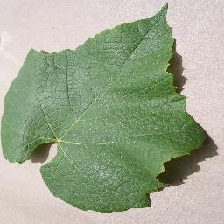

In [ ]:
sample_img_load

In [ ]:
sample_img_to_arr = image.img_to_array(sample_img_load)

In [ ]:
sample_img_to_arr = image.img_to_array(sample_img_load) / 255

In [ ]:
sample_img_to_arr_expand_dim = np.expand_dims(sample_img_to_arr, 0)

In [ ]:
prediction = (model.predict(sample_img_to_arr_expand_dim) > 0.5).astype('int32')

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [ ]:
class_names = ['leaf', 'not_leaf']

In [ ]:
pred_final_result = class_names[prediction[0][0]]

In [ ]:
pred_final_result

'leaf'

## Save the model

In [ ]:
save_model(model, '/content/drive/MyDrive/leaf_or_not_model.keras')

In [ ]:
import os
os.listdir()